In [9]:
print(df.isnull().sum())
print("---")
# Check isic_id matches image filenames
import os
image_folder = r'C:\skin-classifier\data\raw\images'
sample_id = df['isic_id'].iloc[0]
print(f"Sample ID: {sample_id}")
print(f"Expected path: {image_folder}\\{sample_id}.jpg")
print(f"File exists: {os.path.exists(f'{image_folder}\\{sample_id}.jpg')}")

isic_id                       0
attribution                   0
copyright_license             0
age_approx                  383
anatom_site_1               581
anatom_site_2              5804
anatom_site_3              9038
anatom_site_general        2162
anatom_site_special       11183
concomitant_biopsy            0
diagnosis_1                   0
diagnosis_2                   0
diagnosis_3                 180
diagnosis_confirm_type        0
image_manipulation        11719
image_type                    1
lesion_id                     0
melanocytic                   0
sex                         343
dtype: int64
---
Sample ID: ISIC_0024306
Expected path: C:\skin-classifier\data\raw\images\ISIC_0024306.jpg
File exists: True


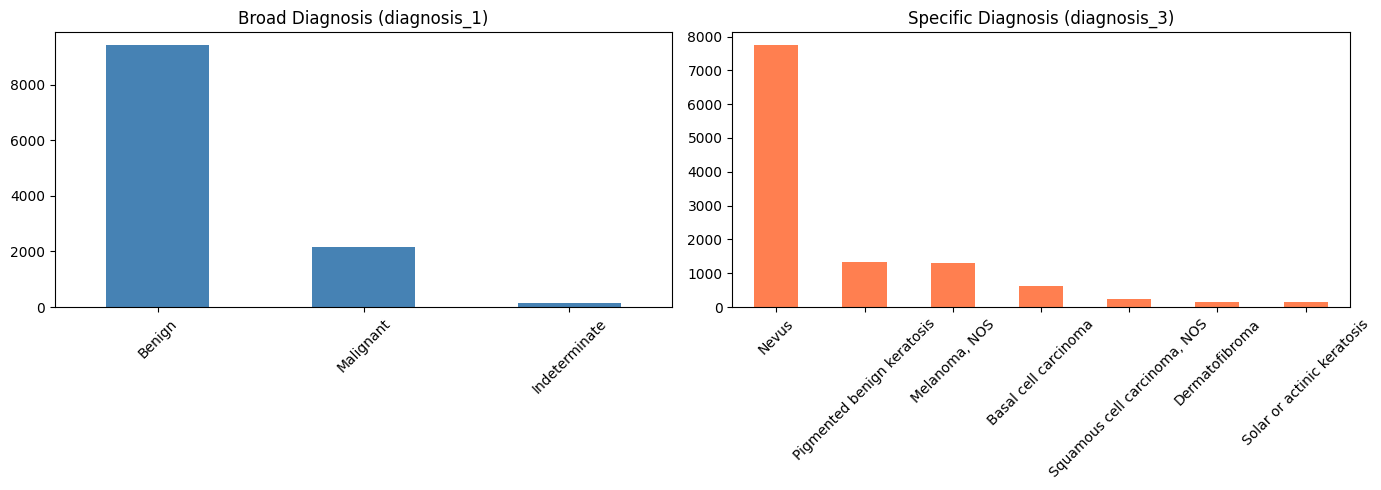

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# diagnosis_1 (broad)
df['diagnosis_1'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Broad Diagnosis (diagnosis_1)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# diagnosis_3 (specific)
df['diagnosis_3'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Specific Diagnosis (diagnosis_3)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

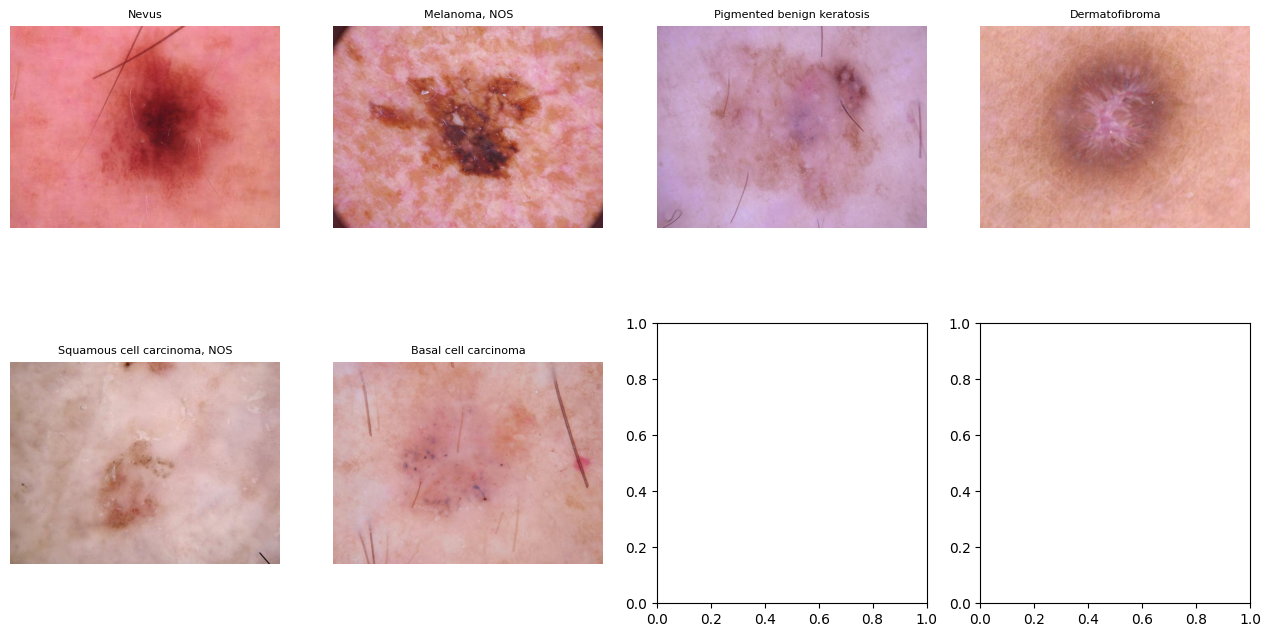

In [15]:
import cv2
import matplotlib.pyplot as plt

classes = df['diagnosis_3'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = df[df['diagnosis_3'] == cls].iloc[0]
    img_path = f"{image_folder}\\{sample['isic_id']}.jpg"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=8)
    axes[i].axis('off')

# hide last empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Map diagnosis_3 to integer labels
label_map = {
    'Nevus': 0,
    'Pigmented benign keratosis': 1,
    'Melanoma, NOS': 2,
    'Basal cell carcinoma': 3,
    'Squamous cell carcinoma, NOS': 4,
    'Dermatofibroma': 5,
    'Solar or actinic keratosis': 6
}

df['label'] = df['diagnosis_3'].map(label_map)
print(df[['isic_id', 'diagnosis_3', 'label']].head(10))
print("---")
print(df['label'].value_counts().sort_index())

        isic_id                 diagnosis_3  label
0  ISIC_0024306                       Nevus    0.0
1  ISIC_0024307                       Nevus    0.0
2  ISIC_0024308                       Nevus    0.0
3  ISIC_0024309                       Nevus    0.0
4  ISIC_0024310               Melanoma, NOS    2.0
5  ISIC_0024311                       Nevus    0.0
6  ISIC_0024312  Pigmented benign keratosis    1.0
7  ISIC_0024313               Melanoma, NOS    2.0
8  ISIC_0024314                       Nevus    0.0
9  ISIC_0024315               Melanoma, NOS    2.0
---
label
0.0    7737
1.0    1338
2.0    1305
3.0     622
4.0     229
5.0     160
6.0     149
Name: count, dtype: int64


In [16]:
df = df.dropna(subset=['diagnosis_3'])
print(f"Rows after dropping NaN diagnosis: {len(df)}")

label_map = {
    'Nevus': 0,
    'Pigmented benign keratosis': 1,
    'Melanoma, NOS': 2,
    'Basal cell carcinoma': 3,
    'Squamous cell carcinoma, NOS': 4,
    'Dermatofibroma': 5,
    'Solar or actinic keratosis': 6
}
df['label'] = df['diagnosis_3'].map(label_map)

Rows after dropping NaN diagnosis: 11540


In [17]:
print("=== Final Dataset Summary ===")
print(f"Total images: {len(df)}")
print(f"Classes: {df['diagnosis_3'].nunique()}")
print(f"\nClass distribution:")
for cls, count in df['diagnosis_3'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {cls:<35} {count:>5} ({pct:.1f}%)")

=== Final Dataset Summary ===
Total images: 11540
Classes: 7

Class distribution:
  Nevus                                7737 (67.0%)
  Pigmented benign keratosis           1338 (11.6%)
  Melanoma, NOS                        1305 (11.3%)
  Basal cell carcinoma                  622 (5.4%)
  Squamous cell carcinoma, NOS          229 (2.0%)
  Dermatofibroma                        160 (1.4%)
  Solar or actinic keratosis            149 (1.3%)


In [19]:
import sys
sys.path.append(r'C:\skin-classifier')

from src.dataset import get_dataloaders

train_loader, val_loader, df = get_dataloaders(batch_size=32)

# Check one batch
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch labels: {labels}")

Train: 9221 | Val: 2319


c:\skin-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([3, 4, 1, 0, 1, 6, 3, 4, 5, 3, 0, 3, 6, 3, 3, 3, 1, 0, 1, 4, 1, 2, 3, 1,
        4, 3, 0, 4, 2, 2, 4, 3])


In [20]:
from src.model import get_model, get_class_weights

model = get_model()

# Test with a real batch
images, labels = next(iter(train_loader))
output = model(images)
print(f"Output shape: {output.shape}")
print(f"Expected:     torch.Size([32, 7])")

# Test class weights
weights = get_class_weights(df)
print(f"\nClass weights: {weights}")
print("Higher weight = rarer class = penalized more when wrong")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

c:\skin-classifier\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ansh9\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Output shape: torch.Size([32, 7])
Expected:     torch.Size([32, 7])

Class weights: tensor([ 0.2131,  1.2321,  1.2633,  2.6504,  7.1990, 10.3036, 11.0642])
Higher weight = rarer class = penalized more when wrong


In [21]:
from src.train import train, DEVICE
print(f"Device: {DEVICE}")
print("train.py imported successfully")

Device: cpu
train.py imported successfully


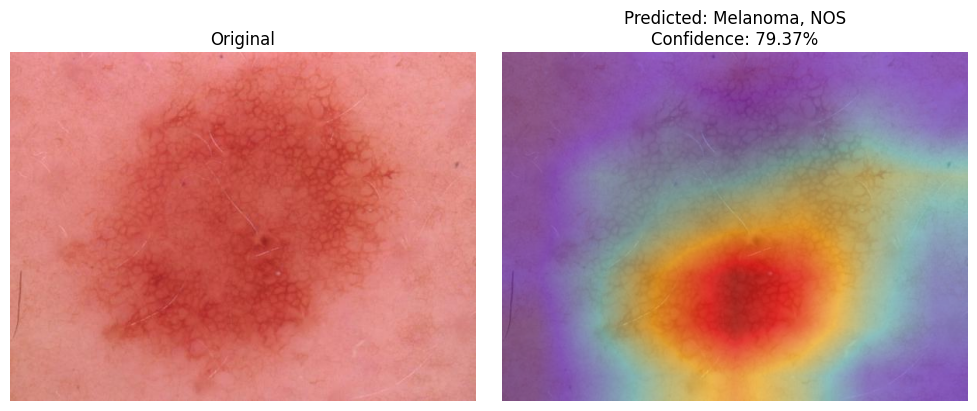

In [22]:
from src.gradcam import predict_and_explain, LABEL_MAP_INV
import matplotlib.pyplot as plt
import cv2

# Load a sample image
sample_row = df.iloc[10]
img_path   = fr'C:\skin-classifier\data\raw\images\{sample_row["isic_id"]}.jpg'
orig_image = cv2.imread(img_path)
orig_image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)

# Preprocess it
from src.dataset import get_transforms
transform    = get_transforms('val')
tensor_image = transform(image=orig_image)['image'].unsqueeze(0)

# Run prediction + heatmap
result = predict_and_explain(model, tensor_image, orig_image)

# Show result
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(result['heatmap'])
axes[1].set_title(f"Predicted: {result['label']}\nConfidence: {result['confidence']:.2%}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(r'C:\skin-classifier\models\history.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Balanced Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best val accuracy: {history['val_acc'].max():.4f} at epoch {history['val_acc'].idxmax()+1}")
print(f"Final train accuracy: {history['train_acc'].iloc[-1]:.4f}")
print(f"Gap (overfitting): {history['train_acc'].iloc[-1] - history['val_acc'].max():.4f}")

EmptyDataError: No columns to parse from file

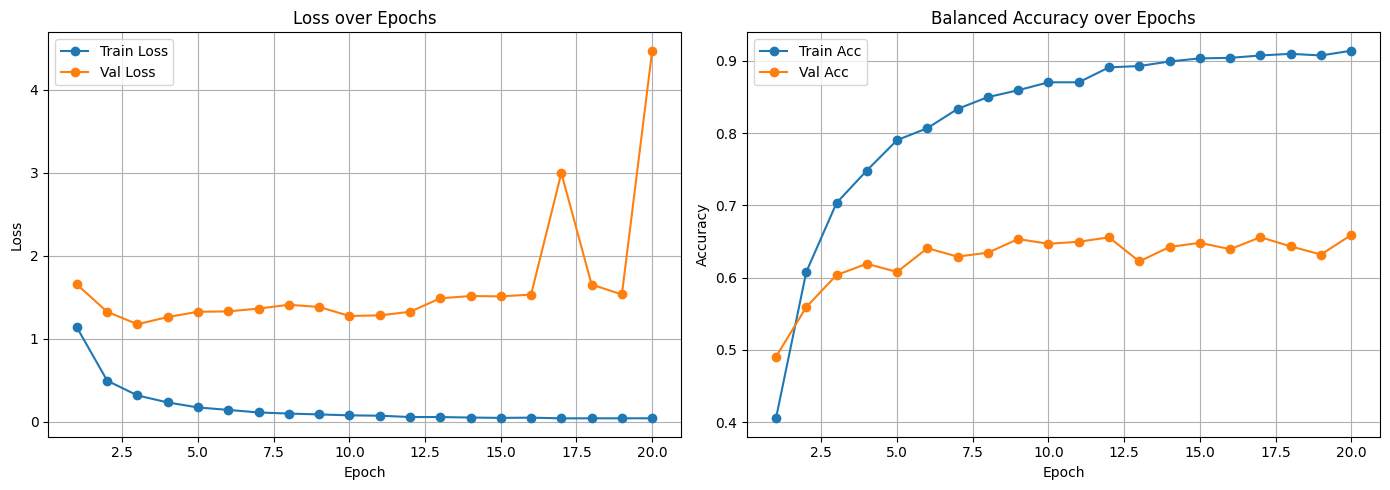

Best val accuracy:      0.6591 at epoch 20
Final train accuracy:   0.9141
Gap (overfitting):      0.2550


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Manually recreate from yesterday's output
history = pd.DataFrame({
    'epoch':      [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    'train_loss': [1.1379,0.4957,0.3179,0.2335,0.1730,0.1437,0.1128,0.0996,0.0890,0.0782,0.0737,0.0577,0.0574,0.0514,0.0475,0.0501,0.0419,0.0423,0.0423,0.0428],
    'train_acc':  [0.4053,0.6078,0.7034,0.7483,0.7904,0.8069,0.8336,0.8499,0.8594,0.8704,0.8704,0.8911,0.8929,0.8992,0.9035,0.9042,0.9075,0.9098,0.9075,0.9141],
    'val_loss':   [1.6561,1.3253,1.1769,1.2629,1.3264,1.3311,1.3653,1.4105,1.3846,1.2758,1.2832,1.3261,1.4887,1.5163,1.5119,1.5339,2.9986,1.6547,1.5352,4.4733],
    'val_acc':    [0.4904,0.5593,0.6036,0.6192,0.6079,0.6408,0.6291,0.6346,0.6534,0.6469,0.6497,0.6558,0.6225,0.6425,0.6482,0.6394,0.6560,0.6433,0.6320,0.6591]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Balanced Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best val accuracy:      {history['val_acc'].max():.4f} at epoch {history['val_acc'].idxmax()+1}")
print(f"Final train accuracy:   {history['train_acc'].iloc[-1]:.4f}")
print(f"Gap (overfitting):      {history['train_acc'].iloc[-1] - history['val_acc'].max():.4f}")


In [4]:
import pandas as pd

df = pd.read_csv(r'C:\skin-classifier\data\raw\ham10000_metadata_2026-03-14.csv')
df = df.dropna(subset=['diagnosis_3'])

In [5]:
# Get one sample image from each class
for cls in df['diagnosis_3'].unique():
    sample = df[df['diagnosis_3'] == cls].iloc[0]
    print(f"{cls:<35} → {sample['isic_id']}.jpg")

Nevus                               → ISIC_0024306.jpg
Melanoma, NOS                       → ISIC_0024310.jpg
Pigmented benign keratosis          → ISIC_0024312.jpg
Dermatofibroma                      → ISIC_0024318.jpg
Squamous cell carcinoma, NOS        → ISIC_0024329.jpg
Basal cell carcinoma                → ISIC_0024331.jpg
Solar or actinic keratosis          → ISIC_0024468.jpg
